✅ Dataset loaded successfully!
   Shape: (208, 61)

EXPLORATORY DATA ANALYSIS
Dataset shape: (208, 61)

First 5 rows:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0     0.0200     0.0371     0.0428     0.0207     0.0954     0.0986   
1     0.0453     0.0523     0.0843     0.0689     0.1183     0.2583   
2     0.0262     0.0582     0.1099     0.1083     0.0974     0.2280   
3     0.0100     0.0171     0.0623     0.0205     0.0205     0.0368   
4     0.0762     0.0666     0.0481     0.0394     0.0590     0.0649   

   Feature_7  Feature_8  Feature_9  Feature_10  ...  Feature_52  Feature_53  \
0     0.1539     0.1601     0.3109      0.2111  ...      0.0027      0.0065   
1     0.2156     0.3481     0.3337      0.2872  ...      0.0084      0.0089   
2     0.2431     0.3771     0.5598      0.6194  ...      0.0232      0.0166   
3     0.1098     0.1276     0.0598      0.1264  ...      0.0121      0.0036   
4     0.1209     0.2467     0.3564      0.4459  ...      0.0

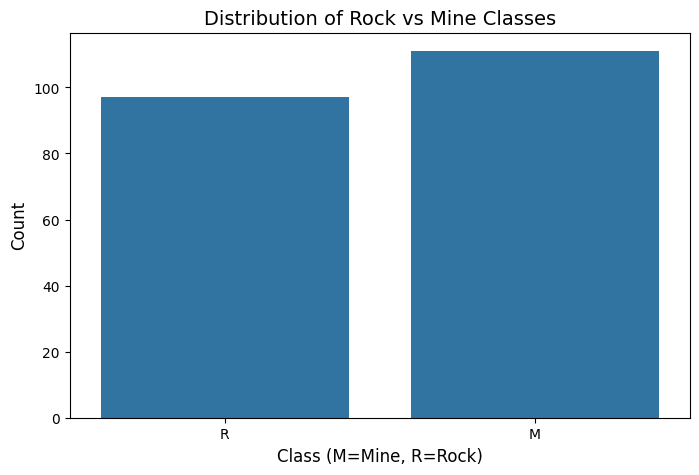


DATA PREPROCESSING
Label encoding: {'M': np.int64(0), 'R': np.int64(1)}
Training set size: 166 samples
Testing set size: 42 samples
Features standardized successfully!

MODEL TRAINING AND EVALUATION

Logistic Regression:
  Accuracy: 0.8333 (83.33%)

  Classification Report:
              precision    recall  f1-score   support

        Rock       0.78      0.95      0.86        22
        Mine       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42



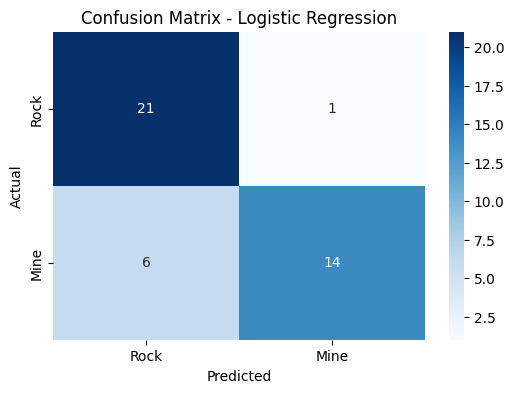


Random Forest:
  Accuracy: 0.8810 (88.10%)

  Classification Report:
              precision    recall  f1-score   support

        Rock       0.81      1.00      0.90        22
        Mine       1.00      0.75      0.86        20

    accuracy                           0.88        42
   macro avg       0.91      0.88      0.88        42
weighted avg       0.90      0.88      0.88        42



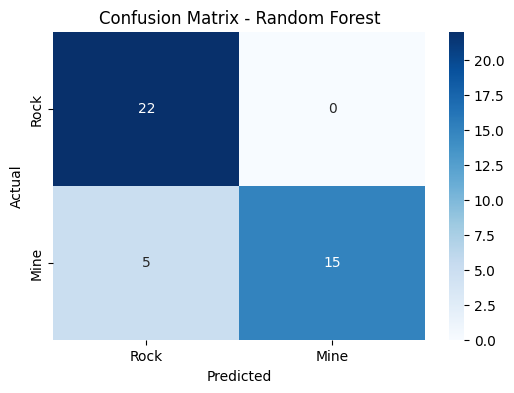


Support Vector Classifier:
  Accuracy: 0.8571 (85.71%)

  Classification Report:
              precision    recall  f1-score   support

        Rock       0.81      0.95      0.88        22
        Mine       0.94      0.75      0.83        20

    accuracy                           0.86        42
   macro avg       0.87      0.85      0.85        42
weighted avg       0.87      0.86      0.86        42



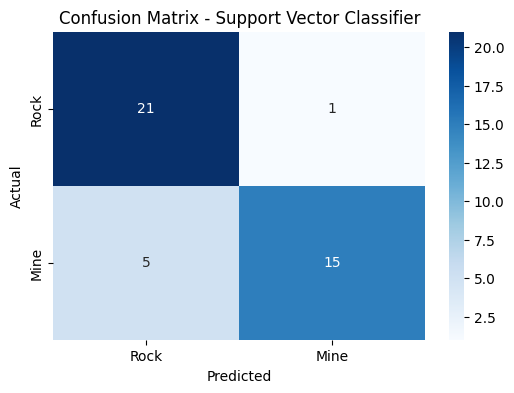


FINAL SUMMARY
🏆 Best Model: Random Forest
   Test Accuracy: 88.10%

✅ Project completed successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Load the dataset with your path ---
file_path = r'C:\Users\ASUS TUF\Desktop\Dataset ML\connectionist+bench+sonar+mines+vs+rocks\sonar.all-data'
column_names = [f'Feature_{i}' for i in range(1, 61)] + ['Class']

try:
    data = pd.read_csv(file_path, header=None, names=column_names)
    print("✅ Dataset loaded successfully!")
    print(f"   Shape: {data.shape}\n")
except FileNotFoundError:
    print(f"❌ File not found at: {file_path}")
    exit()

# --- Exploratory Data Analysis ---
print("="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)
print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nClass distribution:")
print(data['Class'].value_counts())
print("\nMissing values:", data.isnull().sum().sum())

# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=data)
plt.title('Distribution of Rock vs Mine Classes', fontsize=14)
plt.xlabel('Class (M=Mine, R=Rock)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# --- Data Preprocessing ---
print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)

# Separate features and target
X = data.drop('Class', axis=1)
y = data['Class']

# Encode labels (M->1, R->0)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Label encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized successfully!")

# --- Model Training ---
print("\n" + "="*50)
print("MODEL TRAINING AND EVALUATION")
print("="*50)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Support Vector Classifier": SVC(random_state=42, kernel='rbf')
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Rock', 'Mine']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Rock', 'Mine'], 
                yticklabels=['Rock', 'Mine'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# --- Best Model Summary ---
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
best_model = max(results, key=results.get)
print(f"🏆 Best Model: {best_model}")
print(f"   Test Accuracy: {results[best_model]*100:.2f}%")
print("\n✅ Project completed successfully!")

        Feature_1   Feature_2   Feature_3   Feature_4   Feature_5   Feature_6  \
count  208.000000  208.000000  208.000000  208.000000  208.000000  208.000000   
mean     0.029164    0.038437    0.043832    0.053892    0.075202    0.104570   
std      0.022991    0.032960    0.038428    0.046528    0.055552    0.059105   
min      0.001500    0.000600    0.001500    0.005800    0.006700    0.010200   
25%      0.013350    0.016450    0.018950    0.024375    0.038050    0.067025   
50%      0.022800    0.030800    0.034300    0.044050    0.062500    0.092150   
75%      0.035550    0.047950    0.057950    0.064500    0.100275    0.134125   
max      0.137100    0.233900    0.305900    0.426400    0.401000    0.382300   

        Feature_7   Feature_8   Feature_9  Feature_10  ...  Feature_51  \
count  208.000000  208.000000  208.000000  208.000000  ...  208.000000   
mean     0.121747    0.134799    0.178003    0.208259  ...    0.016069   
std      0.061788    0.085152    0.118387    0.1

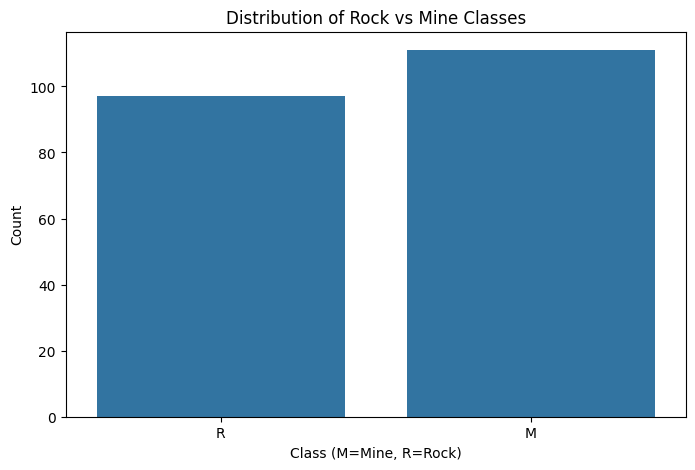

Mines: 111 samples
Rocks: 97 samples
Imbalance ratio: 1.14:1


In [4]:
# Statistical summary
print(data.describe())

# Class distribution visualization
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=data)
plt.title('Distribution of Rock vs Mine Classes')
plt.xlabel('Class (M=Mine, R=Rock)')
plt.ylabel('Count')
plt.show()

# Check for class imbalance
class_counts = data['Class'].value_counts()
print(f"Mines: {class_counts['M']} samples")
print(f"Rocks: {class_counts['R']} samples")
print(f"Imbalance ratio: {class_counts['M']/class_counts['R']:.2f}:1")

In [6]:
# Separate features and target
X = data.drop('Class', axis=1)  # 60 features
y = data['Class']

# Encode labels (M=1, R=0 or vice versa)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # M becomes 1, R becomes 0
print(f"Encoding mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Standardize features (important for SVM and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Encoding mapping: {'M': np.int64(0), 'R': np.int64(1)}
Training set size: 166 samples
Testing set size: 42 samples



Logistic Regression
Training Accuracy: 0.9217 (92.17%)
Testing Accuracy: 0.8333 (83.33%)

Classification Report:
              precision    recall  f1-score   support

        Rock       0.78      0.95      0.86        22
        Mine       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42



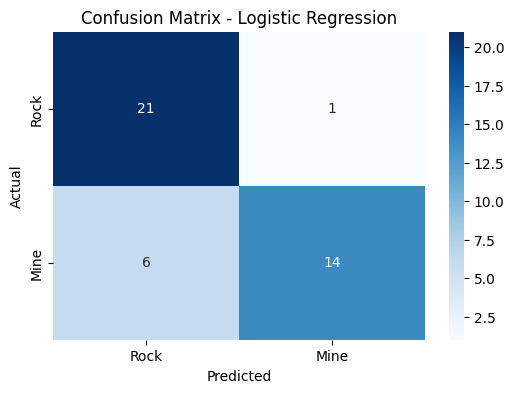


Random Forest
Training Accuracy: 1.0000 (100.00%)
Testing Accuracy: 0.8810 (88.10%)

Classification Report:
              precision    recall  f1-score   support

        Rock       0.81      1.00      0.90        22
        Mine       1.00      0.75      0.86        20

    accuracy                           0.88        42
   macro avg       0.91      0.88      0.88        42
weighted avg       0.90      0.88      0.88        42



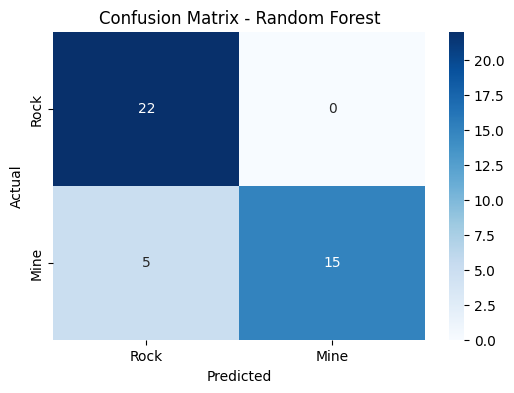


Support Vector Classifier
Training Accuracy: 0.9940 (99.40%)
Testing Accuracy: 0.8571 (85.71%)

Classification Report:
              precision    recall  f1-score   support

        Rock       0.81      0.95      0.88        22
        Mine       0.94      0.75      0.83        20

    accuracy                           0.86        42
   macro avg       0.87      0.85      0.85        42
weighted avg       0.87      0.86      0.86        42



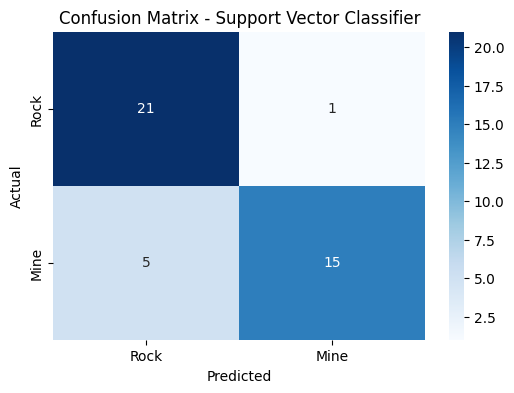

In [7]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Support Vector Classifier": SVC(random_state=42, kernel='rbf')
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Store results
    results[name] = {
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "model": model
    }
    
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"Testing Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_test_pred, target_names=['Rock', 'Mine']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Rock', 'Mine'], 
                yticklabels=['Rock', 'Mine'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [8]:
# Compare all models
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

comparison_df = pd.DataFrame([
    {
        "Model": name,
        "Training Accuracy": f"{results[name]['train_accuracy']*100:.2f}%",
        "Testing Accuracy": f"{results[name]['test_accuracy']*100:.2f}%"
    }
    for name in models.keys()
])

print(comparison_df.to_string(index=False))

# Identify best model
best_model_name = max(results, key=lambda x: results[x]["test_accuracy"])
best_model = results[best_model_name]["model"]
best_accuracy = results[best_model_name]["test_accuracy"]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Testing Accuracy: {best_accuracy*100:.2f}%")


MODEL COMPARISON SUMMARY
                    Model Training Accuracy Testing Accuracy
      Logistic Regression            92.17%           83.33%
            Random Forest           100.00%           88.10%
Support Vector Classifier            99.40%           85.71%

🏆 Best Model: Random Forest
   Testing Accuracy: 88.10%


In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # Suppress the warning

# ... (your existing code for loading data, training models, etc.) ...

# After training your best_model, add this:

def predict_sonar(model, scaler, features, label_encoder, feature_names=None):
    """
    Predict whether sonar signals indicate Rock or Mine.
    """
    # Convert to DataFrame if feature names are provided
    if feature_names is not None:
        # Create DataFrame with proper column names
        if isinstance(features, pd.Series):
            features_df = pd.DataFrame([features.values], columns=feature_names)
        else:
            features_df = pd.DataFrame([features], columns=feature_names)
    else:
        # Fall back to numpy array
        features_df = np.array(features).reshape(1, -1)
    
    # Scale features
    features_scaled = scaler.transform(features_df)
    
    # Predict
    prediction_encoded = model.predict(features_scaled)[0]
    
    # Convert back to original label
    prediction = label_encoder.inverse_transform([prediction_encoded])[0]
    
    return prediction

# Get feature names from your training data
feature_names = X_train.columns.tolist()  # This gets all 60 feature names

# Test multiple samples to verify it works
print("\n" + "="*50)
print("TESTING PREDICTIONS ON 5 SAMPLES")
print("="*50)

correct_predictions = 0
n_samples = min(5, len(X_test))

for i in range(n_samples):
    sample_features = X_test.iloc[i].values
    actual_label = label_encoder.inverse_transform([y_test[i]])[0]
    
    predicted_label = predict_sonar(best_model, scaler, sample_features, label_encoder, feature_names)
    
    is_correct = actual_label == predicted_label
    correct_predictions += is_correct
    
    status = "✅" if is_correct else "❌"
    print(f"{status} Sample {i+1}: Actual={actual_label}, Predicted={predicted_label}")

print(f"\nAccuracy on {n_samples} samples: {correct_predictions/n_samples*100:.1f}%")


TESTING PREDICTIONS ON 5 SAMPLES
✅ Sample 1: Actual=R, Predicted=R
✅ Sample 2: Actual=R, Predicted=R
❌ Sample 3: Actual=R, Predicted=M
✅ Sample 4: Actual=M, Predicted=M
✅ Sample 5: Actual=M, Predicted=M

Accuracy on 5 samples: 80.0%
